# 04 - Latent Simulator

Configure one dataset or a mixed train/validation set, train the shared autoencoder and latent propagator, then identify which physical deformation variables the latent trajectory encodes and inspect autoregressive rollout quality.


In [1]:
from __future__ import annotations

import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from lss.latent.analysis import framewise_latent_descriptor_sweep
from lss.latent.experiment import (
    initial_latent_analysis,
    prepare_source_spec,
    resolve_existing_path,
    result_tables,
    rollout_curve_summary,
    save_result_tables,
    seed_everything,
    train_latent_experiment,
)
from lss.latent.simulation import pearson_r, r2_score
from lss.graph import box_tensor
from lss.utils import resolve_device

plt.rcParams['figure.dpi'] = 110


/home/alexz/Documents/course_project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration


In [ ]:
seed = 42
seed_everything(seed)
print('run seed:', seed)

# Use 'single' for one dataset, or 'mixed' to train/validate on several datasets
# and test on the combined remainder.
run_mode = 'mixed'
selected_dataset = 'depablo'

# Example: train on 20 Reid + 20 dePablo, validate on 20 Reid + 20 dePablo,
# then test on every remaining network from both datasets combined.
dataset_mixture_config = [
    {'dataset': 'reid', 'train_count': 10, 'val_count': 5},
    {'dataset': 'depablo', 'train_count': 10, 'val_count': 5},
]

dataset_specs = {
    'reid': {
        'label': 'Reid',
        'path': 'data/reid_200_frames.pt',
        'train_count': 10,
        'val_count': 10,
    },
    'depablo': {
        'label': 'dePablo',
        'path': 'data/2340_dePablo_networks_OOL_undirected.pt',
        'train_count': 10,
        'val_count': 5,
    },
    'depablo-10k-mix-temp': {
        'label': 'dePablo 10k mixed temperature',
        'path': 'data/depablo-10k-mix-temp.pt',
        'train_count': 80,
        'val_count': 50,
    },
    'noizy': {
        'label': 'Noizy',
        'path': 'data/200_rand_pruned_OOL_bidirect_val1057.pt',
        'train_count': 140,
        'val_count': 30,
    },
}

AE_COORDINATE_MODE = 'normalized_delta'
BATCH_GRAPHS = 4
PROPAGATOR_PRESETS = {
    'residual_mlp': {
        'propagator_objective': 'one_step',
        'propagator_model': 'residual_mlp',
        'propagator_loss': 'delta',
    },
    'direct_mlp': {
        'propagator_objective': 'one_step',
        'propagator_model': 'direct_mlp',
        'propagator_loss': 'next_z',
    },
    'linear': {
        'propagator_objective': 'one_step',
        'propagator_model': 'linear',
        'propagator_loss': 'delta',
    },
    'velocity_mlp': {
        'propagator_objective': 'velocity',
        'propagator_model': 'velocity_mlp',
        'propagator_loss': 'velocity_delta',
    },
}

cfg = {
    'dataset_name': selected_dataset,
    'split_seed': seed,
    # Balance temperature groups only when the selected dataset provides them.
    'split_stratify_temperature': selected_dataset == 'depablo-10k-mix-temp',
    # Only applies to single-dataset runs. Mixture runs disable it below.
    'min_train_p_ratio': None,
    'device': 'auto',
    'pos_dim': 2,
    'frame_skip': 1,
    # Include the undeformed state because every rollout starts from frame 0.
    'train_frame_start_order': 0,
    'latent_dim': 6,
    'latent_tokens': 32,
    'hidden_size': 96,
    'edge_feature_dim': 12,
    'ae_max_train_frames_per_sim': 30,
    'dyn_max_train_transitions_per_sim': 30,
    'ae_max_epochs': 300,
    'ae_patience': 5,
    'ae_lr': 5e-5,
    'ae_weight_decay': 1e-5,
    'dyn_max_epochs': 300,
    'dyn_patience': 5,
    'dyn_lr': 3e-5,
    'dyn_weight_decay': 1e-4,

    # Condition every latent update on reference geometry, topology and stiffness.
    'propagator_use_static_context': True,
    'graph_context_dim': 16,
    'propagator_context_include_temperature': False,

    # The propagator learns z(t) -> z(t+5); rollout repeats that 5-frame jump.
    'propagator_step_stride': 5,
    'initial_velocity': 'zero',
    'propagator_type': 'residual_mlp',
    'early_stop_min_delta': 1e-5,
    'rollout_steps_grid': [10, 20, 50, 100, 150, 200],
    'temperature_pratio_window': 'full',
    # Use evenly spaced frames for the interpretation sweep; first/final are retained.
    'descriptor_max_frames_per_sim': 60,
    'output_root': '../results/latent_space_simulator',
}

if cfg['propagator_type'] not in PROPAGATOR_PRESETS:
    raise ValueError(f"Unknown propagator_type: {cfg['propagator_type']}")
cfg.update({
    'batch_graphs': BATCH_GRAPHS,
    'ae_target_mode': AE_COORDINATE_MODE,
    'node_feature_mode': AE_COORDINATE_MODE,
})
cfg.update(PROPAGATOR_PRESETS[cfg['propagator_type']])

if run_mode in {'mixed', 'mixture'}:
    cfg['dataset_name'] = 'mixed'
    cfg['split_stratify_temperature'] = False
    cfg['min_train_p_ratio'] = None
    mixture_sources = []
    labels = []
    for item in dataset_mixture_config:
        dataset_name = item['dataset']
        base = dataset_specs[dataset_name]
        labels.append(base['label'])
        mixture_sources.append({
            'name': dataset_name,
            'label': base['label'],
            'path': resolve_existing_path(base['path']),
            'train_count': int(item['train_count']),
            'val_count': int(item['val_count']),
        })
    source_spec = {
        'dataset_name': 'mixed',
        'source_name': '+'.join(labels),
        'label': f"{'+'.join(labels)} CV{cfg['latent_dim']} {cfg['ae_target_mode']}",
        'path': mixture_sources[0]['path'],
        'dataset_mixture': mixture_sources,
        'target_mode': cfg['ae_target_mode'],
        'ae_target_mode': cfg['ae_target_mode'],
        'node_feature_mode': cfg['node_feature_mode'],
        'latent_dim': int(cfg['latent_dim']),
        'repeat_idx': int(cfg.get('repeat_idx', 1)),
        'model_seed': int(cfg.get('model_seed', seed + 1009 * int(cfg['latent_dim']))),
        'latent_tokens': int(cfg['latent_tokens']),
        'hidden_size': int(cfg['hidden_size']),
        'edge_feature_dim': int(cfg.get('edge_feature_dim', 0)),
        'ae_max_train_frames_per_sim': int(cfg['ae_max_train_frames_per_sim']),
        'dyn_max_train_transitions_per_sim': int(cfg['dyn_max_train_transitions_per_sim']),
        'ae_max_epochs': int(cfg['ae_max_epochs']),
        'ae_patience': int(cfg['ae_patience']),
        'ae_lr': float(cfg['ae_lr']),
        'ae_weight_decay': float(cfg['ae_weight_decay']),
        'dyn_max_epochs': int(cfg['dyn_max_epochs']),
        'dyn_patience': int(cfg['dyn_patience']),
        'dyn_lr': float(cfg['dyn_lr']),
        'dyn_weight_decay': float(cfg['dyn_weight_decay']),
    }
    run_name = 'mixed_' + '_'.join(
        f"{item['dataset']}_tr{int(item['train_count'])}_val{int(item['val_count'])}"
        for item in dataset_mixture_config
    )
else:
    source_spec = prepare_source_spec(selected_dataset, dataset_specs, cfg, seed=seed)
    run_name = selected_dataset

device = resolve_device(cfg['device'])
run_dir = Path(cfg['output_root']) / run_name / 'cv04_rollout_stride5_selfnorm_static'
run_dir.mkdir(parents=True, exist_ok=True)

print('run mode:', run_mode)
print('dataset:', cfg['dataset_name'])
print('device:', device)
print('output:', run_dir)
display(pd.DataFrame([source_spec]))
if run_mode in {'mixed', 'mixture'}:
    display(pd.DataFrame(source_spec['dataset_mixture']))


run seed: 360971551
run mode: mixed
dataset: mixed
device: cuda
output: ../results/latent_space_simulator/mixed_reid_tr10_val10_depablo_tr10_val10/cv04_rollout_stride5_selfnorm_static


,dataset_name,source_name,label,path,dataset_mixture,target_mode,ae_target_mode,node_feature_mode,latent_dim,repeat_idx,...,ae_max_train_frames_per_sim,dyn_max_train_transitions_per_sim,ae_max_epochs,ae_patience,ae_lr,ae_weight_decay,dyn_max_epochs,dyn_patience,dyn_lr,dyn_weight_decay
0,mixed,Reid+dePablo,Reid+dePablo CV6 normalized_delta,/home/alexz/Documents/course_project/data/reid...,"[{'name': 'reid', 'label': 'Reid', 'path': '/h...",normalized_delta,normalized_delta,normalized_delta,6,1,...,20,20,300,5,0.00005,0.00001,300,5,0.00003,0.0001


,name,label,path,train_count,val_count
0,reid,Reid,/home/alexz/Documents/course_project/data/reid...,10,10
1,depablo,dePablo,/home/alexz/Documents/course_project/data/depa...,10,10


## Train Autoencoder And Latent Propagator



=== Reid+dePablo CV6 normalized_delta ===
 source                                                                path  total  train  val  test
   reid        /home/alexz/Documents/course_project/data/reid_200_frames.pt    102     10   10    82
depablo /home/alexz/Documents/course_project/data/depablo-near-zero-temp.pt    200     10   10   180
autoencoder
ae 0001 train=0.92258 val=0.519631 stale=0
ae 0002 train=0.580964 val=0.432298 stale=0
ae 0003 train=0.538359 val=0.420927 stale=0
ae 0004 train=0.531885 val=0.414864 stale=0
ae 0005 train=0.51906 val=0.408937 stale=0
ae 0007 train=0.5044 val=0.405216 stale=0
ae 0008 train=0.491453 val=0.399141 stale=0
ae 0010 train=0.459647 val=0.386639 stale=0
ae 0011 train=0.451154 val=0.377325 stale=0
ae 0012 train=0.428757 val=0.369339 stale=0
ae 0013 train=0.405589 val=0.348105 stale=0
ae 0015 train=0.366241 val=0.330746 stale=0
ae 0016 train=0.347849 val=0.312484 stale=0
ae 0017 train=0.325799 val=0.301183 stale=0
ae 0018 train=0.301281 val=0.2

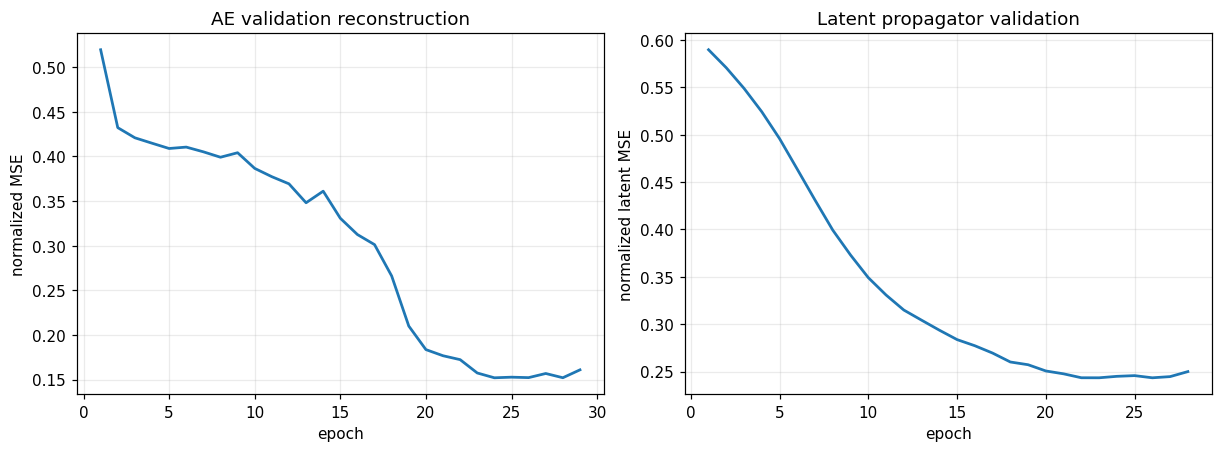

AE-only teacher-forced reconstruction (no propagator)


,dataset,split,rollout_steps,used,p_ratio_r2,p_ratio_pearson,p_ratio_mse,final_pos_mse,initial_to_target_mse,pred_to_initial_mse,movement_fraction_mse,rollout_error_fraction,rollout_position_r2,transverse_pos_mse,latent_dim,repeat_idx,model_seed,run_label
0,Reid+dePablo CV6 normalized_delta,val,10,20,0.924637,0.964743,0.002782,0.000001,0.000021,0.000021,1.018407,0.071285,0.928715,0.000001,6,1,360977605,Reid+dePablo CV6 normalized_delta
1,Reid+dePablo CV6 normalized_delta,val,20,20,0.931577,0.972092,0.002965,0.000008,0.000085,0.000079,0.936012,0.093980,0.906020,0.000003,6,1,360977605,Reid+dePablo CV6 normalized_delta
2,Reid+dePablo CV6 normalized_delta,val,50,20,0.757136,0.933698,0.011877,0.000122,0.000545,0.000477,0.875310,0.224308,0.775692,0.000041,6,1,360977605,Reid+dePablo CV6 normalized_delta
3,Reid+dePablo CV6 normalized_delta,val,100,20,0.235938,0.673056,0.040374,0.000839,0.002227,0.002032,0.912418,0.376863,0.623137,0.000296,6,1,360977605,Reid+dePablo CV6 normalized_delta
4,Reid+dePablo CV6 normalized_delta,val,150,20,-0.248685,0.513160,0.069875,0.002521,0.005079,0.004994,0.983138,0.496413,0.503587,0.000924,6,1,360977605,Reid+dePablo CV6 normalized_delta
5,Reid+dePablo CV6 normalized_delta,val,199,20,-1.578914,0.136192,0.151767,0.005390,0.009039,0.009327,1.031858,0.596267,0.403733,0.002024,6,1,360977605,Reid+dePablo CV6 normalized_delta
6,Reid+dePablo CV6 normalized_delta,test,10,262,0.957741,0.982764,0.002415,0.000002,0.000023,0.000024,1.020056,0.067941,0.932059,0.000001,6,1,360977605,Reid+dePablo CV6 normalized_delta
7,Reid+dePablo CV6 normalized_delta,test,20,262,0.963280,0.982742,0.002517,0.000009,0.000095,0.000097,1.018754,0.093958,0.906042,0.000004,6,1,360977605,Reid+dePablo CV6 normalized_delta
8,Reid+dePablo CV6 normalized_delta,test,50,262,0.854563,0.932803,0.011390,0.000163,0.000611,0.000716,1.172523,0.267074,0.732926,0.000060,6,1,360977605,Reid+dePablo CV6 normalized_delta
9,Reid+dePablo CV6 normalized_delta,test,100,262,0.571065,0.806961,0.036185,0.001188,0.002486,0.003178,1.278133,0.477779,0.522221,0.000359,6,1,360977605,Reid+dePablo CV6 normalized_delta


,dataset,split,rollout_steps,used,p_ratio_r2,p_ratio_pearson,p_ratio_mse,final_pos_mse,initial_to_target_mse,pred_to_initial_mse,movement_fraction_mse,rollout_error_fraction,rollout_position_r2,latent_dim,repeat_idx,model_seed,run_label
0,Reid+dePablo CV6 normalized_delta,train,10,20,0.83709,0.91875,0.00819,0.00000,0.00002,0.00002,0.95159,0.05999,0.94001,6,1,360977605,Reid+dePablo CV6 normalized_delta
1,Reid+dePablo CV6 normalized_delta,train,20,20,0.86240,0.93066,0.00808,0.00001,0.00008,0.00007,0.87538,0.09041,0.90959,6,1,360977605,Reid+dePablo CV6 normalized_delta
2,Reid+dePablo CV6 normalized_delta,train,50,20,0.51219,0.90283,0.03211,0.00012,0.00051,0.00036,0.69068,0.23566,0.76434,6,1,360977605,Reid+dePablo CV6 normalized_delta
3,Reid+dePablo CV6 normalized_delta,train,100,20,-1.99005,0.85134,0.21131,0.00096,0.00211,0.00102,0.48530,0.45402,0.54598,6,1,360977605,Reid+dePablo CV6 normalized_delta
4,Reid+dePablo CV6 normalized_delta,train,150,20,-4.28013,0.74487,0.39217,0.00298,0.00482,0.00215,0.44656,0.61705,0.38295,6,1,360977605,Reid+dePablo CV6 normalized_delta
5,Reid+dePablo CV6 normalized_delta,train,195,20,-2.63452,0.73947,0.28062,0.00613,0.00825,0.00453,0.54831,0.74260,0.25740,6,1,360977605,Reid+dePablo CV6 normalized_delta
6,Reid+dePablo CV6 normalized_delta,val,10,20,0.78389,0.88669,0.00798,0.00000,0.00002,0.00002,1.07135,0.07124,0.92876,6,1,360977605,Reid+dePablo CV6 normalized_delta
7,Reid+dePablo CV6 normalized_delta,val,20,20,0.81134,0.90847,0.00817,0.00001,0.00008,0.00008,0.97632,0.10000,0.90000,6,1,360977605,Reid+dePablo CV6 normalized_delta
8,Reid+dePablo CV6 normalized_delta,val,50,20,0.39762,0.90227,0.02946,0.00012,0.00054,0.00042,0.77302,0.22604,0.77396,6,1,360977605,Reid+dePablo CV6 normalized_delta
9,Reid+dePablo CV6 normalized_delta,val,100,20,-2.76000,0.85575,0.19869,0.00092,0.00223,0.00119,0.53371,0.41342,0.58658,6,1,360977605,Reid+dePablo CV6 normalized_delta


In [3]:
seed_everything(source_spec['model_seed'])
result = train_latent_experiment(source_spec, cfg, device=device)
results = [result]

tables = result_tables(results)
save_result_tables(tables, run_dir)

ae_history_df = tables['ae_history']
dyn_history_df = tables['dyn_history']
rollout_rows_df = tables['rollout_rows']
rollout_stats_df = tables['rollout_stats']
ae_reconstruction_rows_df = tables['ae_reconstruction_rows']
ae_reconstruction_stats_df = tables['ae_reconstruction_stats']

source_names = sorted({
    str(value)
    for frame in (rollout_rows_df, ae_reconstruction_rows_df)
    if 'source' in frame
    for value in frame['source'].dropna().unique()
})
source_palette = {
    source: color
    for source, color in zip(source_names, plt.rcParams['axes.prop_cycle'].by_key()['color'])
}

def scatter_by_source(ax, frame, x_col, y_col, *, s=28, alpha=0.75):
    if 'source' not in frame or frame['source'].nunique(dropna=True) <= 1:
        ax.scatter(frame[x_col], frame[y_col], s=s, alpha=alpha, color='tab:blue')
        return False
    for source, group in frame.groupby('source', sort=True):
        ax.scatter(
            group[x_col], group[y_col], s=s, alpha=alpha,
            color=source_palette.get(str(source)), label=str(source),
        )
    return True

print(
    'propagator conditioning:',
    'frame-0 graph context enabled' if cfg['propagator_use_static_context'] else 'no static context',
    f"| raw reference embedding={cfg['hidden_size']}D",
    f"| projected context={cfg['graph_context_dim']}D",
    f"| dynamics={cfg['propagator_objective']}",
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].plot(ae_history_df['epoch'], ae_history_df['val_mse_norm'], lw=1.8)
axes[0].set(title='AE validation reconstruction', xlabel='epoch', ylabel='normalized MSE')
axes[1].plot(dyn_history_df['epoch'], dyn_history_df['val_dz_mse_norm'], lw=1.8)
axes[1].set(title='Latent propagator validation', xlabel='epoch', ylabel='normalized latent MSE')
for ax in axes:
    ax.grid(alpha=0.25)
plt.show()

print('AE-only teacher-forced reconstruction (no propagator)')
display(ae_reconstruction_stats_df.round(6))

display(rollout_stats_df.round(5))


## Initial Latent P-Ratio Baseline

This is retained as a diagnostic, not as the primary interpretation. If the initial latent does not generalize to final p-ratio, the trajectory descriptor sweep below determines what the representation actually encodes.


No varying temperature metadata; skipping temperature-adjusted readouts.


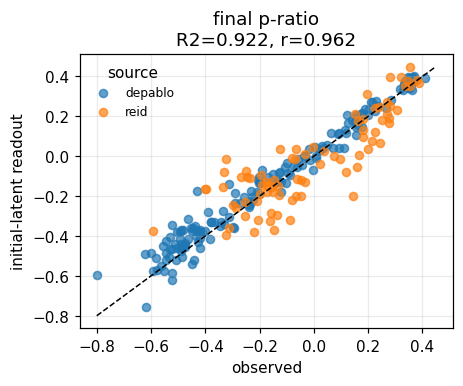

Linear combination used all coordinates: z0, z1, z2, z3, z4, z5
final p-ratio: test R2=0.922, r=0.962


In [4]:
latent_df, latent_corr_df = initial_latent_analysis(results, device=device)
latent_df.to_csv(run_dir / 'initial_latent_table.csv', index=False)
latent_corr_df.to_csv(run_dir / 'initial_latent_p_ratio_correlations.csv', index=False)

z_cols = sorted(
    [col for col in latent_df if col.startswith('z')],
    key=lambda col: int(col[1:]),
)
val_latent = latent_df[latent_df['split'].eq('val')].copy()
test_latent = latent_df[latent_df['split'].eq('test')].copy()

targets = {
    'final_p_ratio': 'final p-ratio',
}
temp_val_raw = val_latent['temperature'].to_numpy(float)
temp_test_raw = test_latent['temperature'].to_numpy(float)
has_temperature = (
    np.isfinite(temp_val_raw).all()
    and np.isfinite(temp_test_raw).all()
    and np.unique(temp_val_raw).size > 1
)
if has_temperature:
    # Ask whether z contains response information beyond temperature.
    temp_val = np.log1p(temp_val_raw)
    temp_test = np.log1p(temp_test_raw)
    temp_design_val = np.column_stack([np.ones(len(temp_val)), temp_val])
    temp_coef = np.linalg.lstsq(
        temp_design_val, val_latent['final_p_ratio'].to_numpy(float), rcond=None,
    )[0]
    val_latent['temperature_adjusted_p_ratio'] = (
        val_latent['final_p_ratio'] - temp_design_val @ temp_coef
    )
    test_latent['temperature_adjusted_p_ratio'] = (
        test_latent['final_p_ratio']
        - np.column_stack([np.ones(len(temp_test)), temp_test]) @ temp_coef
    )
    targets.update({
        'temperature': 'temperature',
        'temperature_adjusted_p_ratio': 'temp-adjusted p-ratio',
    })
else:
    print('No varying temperature metadata; skipping temperature-adjusted readouts.')
X_val = val_latent[z_cols].to_numpy(float)
X_test = test_latent[z_cols].to_numpy(float)
x_mean = X_val.mean(axis=0)
x_std = X_val.std(axis=0) + 1e-12
design_val = np.column_stack([np.ones(len(X_val)), (X_val - x_mean) / x_std])
design_test = np.column_stack([np.ones(len(X_test)), (X_test - x_mean) / x_std])

readout_rows = []
weight_rows = []
test_predictions = {}
for target, label in targets.items():
    y_val = val_latent[target].to_numpy(float)
    y_test = test_latent[target].to_numpy(float)
    coef = np.linalg.lstsq(design_val, y_val, rcond=None)[0]
    pred = design_test @ coef
    test_predictions[target] = pred
    readout_rows.append({
        'target': label,
        'test_r2': r2_score(y_test, pred),
        'test_pearson_r': pearson_r(y_test, pred),
    })
    weight_rows.append({
        'target': label,
        'intercept': float(coef[0] - np.sum(coef[1:] * x_mean / x_std)),
        **{f'{col}_weight': float(weight) for col, weight in zip(z_cols, coef[1:] / x_std)},
    })

latent_readout_df = pd.DataFrame(readout_rows)
latent_readout_weights_df = pd.DataFrame(weight_rows)
latent_readout_df.to_csv(run_dir / 'initial_latent_linear_readout_scores.csv', index=False)
latent_readout_weights_df.to_csv(run_dir / 'initial_latent_linear_readout_weights.csv', index=False)

fig, axes = plt.subplots(
    1, len(targets), figsize=(4.1 * len(targets), 3.4), constrained_layout=True,
)
axes = np.atleast_1d(axes)
for ax, (target, label) in zip(axes, targets.items()):
    observed = test_latent[target].to_numpy(float)
    predicted = test_predictions[target]
    score = latent_readout_df.loc[latent_readout_df['target'].eq(label)].iloc[0]
    plot_df = test_latent.assign(_observed=observed, _predicted=predicted)
    used_source_color = scatter_by_source(
        ax, plot_df, '_observed', '_predicted', s=28, alpha=0.7,
    )
    finite = np.isfinite(observed) & np.isfinite(predicted)
    if finite.any():
        lo = min(observed[finite].min(), predicted[finite].min())
        hi = max(observed[finite].max(), predicted[finite].max())
        ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
    ax.set(
        title=f'{label}\nR2={score.test_r2:.3f}, r={score.test_pearson_r:.3f}',
        xlabel='observed', ylabel='initial-latent readout',
    )
    ax.grid(alpha=0.25)
if any('source' in test_latent and test_latent['source'].nunique(dropna=True) > 1 for _ in [0]):
    axes[-1].legend(frameon=False, fontsize=8, title='source')
plt.show()

print('Linear combination used all coordinates:', ', '.join(z_cols))
for row in latent_readout_df.itertuples(index=False):
    print(f'{row.target}: test R2={row.test_r2:.3f}, r={row.test_pearson_r:.3f}')


## Example Node Motion During Compression

For one held-out network, select representative nodes near the left, center, right, top, and bottom. The small plots show each node's position change as the network's horizontal strain changes. Horizontal strain here means `(current width - initial width) / initial width`; negative values are compression.


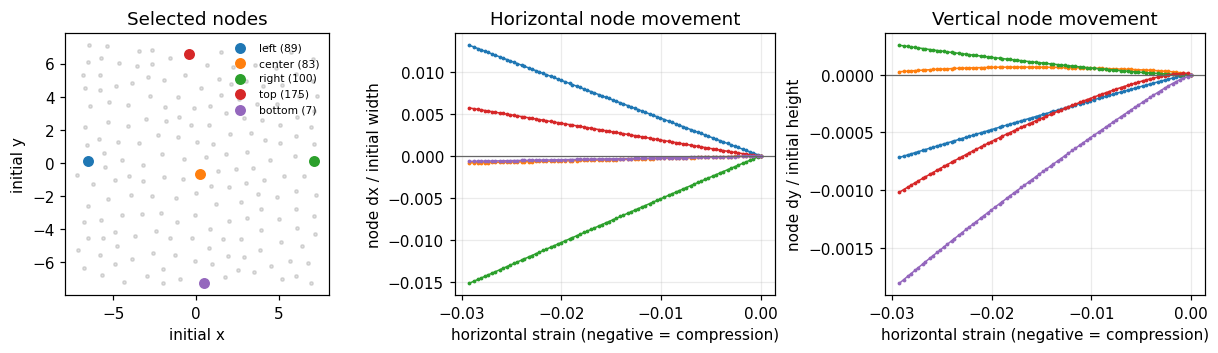

In [5]:
motion_sets = [
    result.get('test_data', []),
    result.get('val_data', []),
    result.get('train_data', []),
]
motion_sim = next((sims[0] for sims in motion_sets if len(sims)), None)
if motion_sim is None:
    raise ValueError('No simulations available for node-motion plot.')

ref_pos = motion_sim[0].x[:, :2].detach().cpu().numpy()
ref_span = np.ptp(ref_pos, axis=0)
ref_span = np.where(ref_span > 1e-12, ref_span, 1.0)
center = ref_pos.mean(axis=0)

node_targets = {
    'left': np.array([ref_pos[:, 0].min(), center[1]]),
    'center': center,
    'right': np.array([ref_pos[:, 0].max(), center[1]]),
    'top': np.array([center[0], ref_pos[:, 1].max()]),
    'bottom': np.array([center[0], ref_pos[:, 1].min()]),
}
selected_nodes = {}
used_nodes = set()
for label, target in node_targets.items():
    distances = np.linalg.norm(ref_pos - target[None, :], axis=1)
    for node_idx in np.argsort(distances):
        node_idx = int(node_idx)
        if node_idx not in used_nodes:
            selected_nodes[label] = node_idx
            used_nodes.add(node_idx)
            break

frame_count = min(len(motion_sim), 80)
frame_ids = np.unique(np.linspace(0, len(motion_sim) - 1, frame_count, dtype=int))
horizontal_strain = []
node_dx = {label: [] for label in selected_nodes}
node_dy = {label: [] for label in selected_nodes}
for frame_idx in frame_ids:
    pos = motion_sim[int(frame_idx)].x[:, :2].detach().cpu().numpy()
    horizontal_strain.append(np.ptp(pos[:, 0]) / ref_span[0] - 1.0)
    for label, node_idx in selected_nodes.items():
        node_dx[label].append((pos[node_idx, 0] - ref_pos[node_idx, 0]) / ref_span[0])
        node_dy[label].append((pos[node_idx, 1] - ref_pos[node_idx, 1]) / ref_span[1])

fig, axes = plt.subplots(1, 3, figsize=(11, 3.1), constrained_layout=True)
axes[0].scatter(ref_pos[:, 0], ref_pos[:, 1], s=5, alpha=0.18, color='0.35')
for label, node_idx in selected_nodes.items():
    axes[0].scatter(*ref_pos[node_idx], s=38, label=f'{label} ({node_idx})')
axes[0].set(title='Selected nodes', xlabel='initial x', ylabel='initial y', aspect='equal')
axes[0].legend(fontsize=7, frameon=False)

for label in selected_nodes:
    axes[1].plot(horizontal_strain, node_dx[label], marker='.', ms=3, lw=1, label=label)
    axes[2].plot(horizontal_strain, node_dy[label], marker='.', ms=3, lw=1, label=label)
axes[1].set(
    title='Horizontal node movement',
    xlabel='horizontal strain (negative = compression)',
    ylabel='node dx / initial width',
)
axes[2].set(
    title='Vertical node movement',
    xlabel='horizontal strain (negative = compression)',
    ylabel='node dy / initial height',
)
for ax in axes[1:]:
    ax.axhline(0, color='0.4', lw=0.8)
    ax.grid(alpha=0.25)
plt.show()


## Strain-Stress Curves

For a few held-out trajectories, estimate a simple elastic stress proxy from edge stretch and stiffness, then plot it against horizontal strain. Curves are colored by dataset source when running mixed datasets.


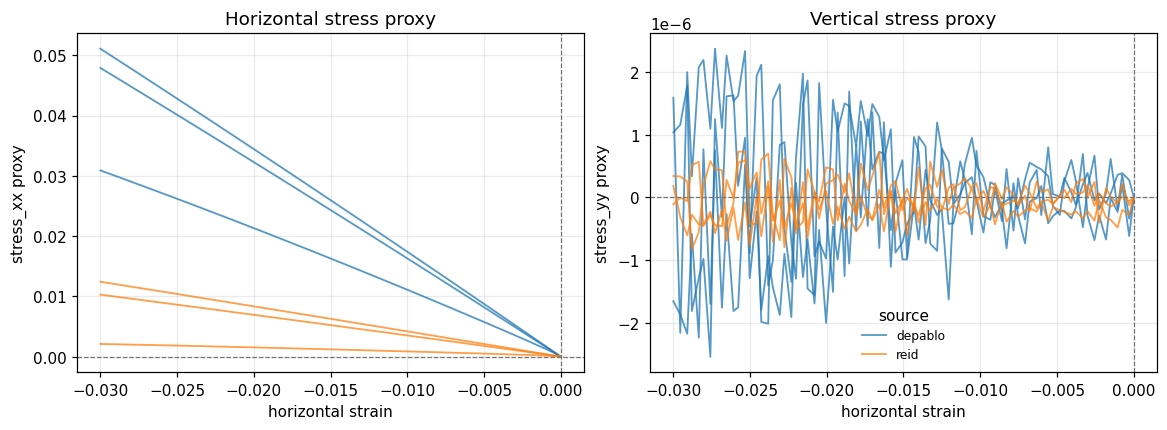

stress_xx_proxy          stress_yy_proxy     
                    min      max             min  max
source                                               
depablo            -0.0  0.05109            -0.0  0.0
reid               -0.0  0.01245            -0.0  0.0

In [6]:
def graph_box_width_height(graph):
    maybe_box = box_tensor(graph)
    if maybe_box is not None:
        return maybe_box.detach().cpu().float().numpy()[:2]
    pos = graph.x[:, :2].detach().cpu().float().numpy()
    span = np.ptp(pos, axis=0)
    return np.where(span > 1e-12, span, 1.0)


def elastic_stress_curve(sim, *, max_frames=80):
    if not sim or not hasattr(sim[0], 'edge_attr') or sim[0].edge_attr is None:
        return pd.DataFrame()
    edge_attr0 = sim[0].edge_attr.detach().cpu().float()
    if edge_attr0.numel() == 0:
        return pd.DataFrame()

    row, col = sim[0].edge_index.detach().cpu().long()
    box0 = graph_box_width_height(sim[0])
    pos0 = sim[0].x[:, :2].detach().cpu().float()
    delta0 = pos0[row] - pos0[col]
    delta0_np = delta0.numpy()
    if np.all(np.isfinite(box0)) and np.all(box0 > 1e-12):
        delta0_np = delta0_np - np.round(delta0_np / box0[None, :]) * box0[None, :]
    dist0 = np.linalg.norm(delta0_np, axis=1)
    r0 = edge_attr0[:, -2].numpy() if edge_attr0.shape[1] >= 2 else dist0
    stiffness = edge_attr0[:, -1].numpy()

    frame_ids = np.unique(np.linspace(0, len(sim) - 1, min(len(sim), max_frames), dtype=int))
    rows = []
    for frame_idx in frame_ids:
        graph = sim[int(frame_idx)]
        pos = graph.x[:, :2].detach().cpu().float()
        box = graph_box_width_height(graph)
        delta = (pos[row] - pos[col]).numpy()
        if np.all(np.isfinite(box)) and np.all(box > 1e-12):
            delta = delta - np.round(delta / box[None, :]) * box[None, :]
        dist = np.linalg.norm(delta, axis=1) + 1e-12
        force_mag = -2.0 * stiffness * (dist - r0)
        ratio = force_mag / dist
        area = float(max(box[0] * box[1], 1e-12))
        stress_xx = 0.5 * float(np.sum(ratio * delta[:, 0] ** 2)) / area
        stress_yy = 0.5 * float(np.sum(ratio * delta[:, 1] ** 2)) / area
        rows.append({
            'frame_idx': int(frame_idx),
            'source': str(getattr(sim[0], 'source_name', 'dataset')),
            'horizontal_strain': float(box[0] / box0[0] - 1.0),
            'vertical_strain': float(box[1] / box0[1] - 1.0),
            'stress_xx_proxy': stress_xx,
            'stress_yy_proxy': stress_yy,
        })
    return pd.DataFrame(rows)


stress_sims = []
for source, group in pd.DataFrame({
    'idx': range(len(result['test_data'])),
    'source': [str(getattr(sim[0], 'source_name', result.get('source_name', result['label']))) for sim in result['test_data']],
}).groupby('source', sort=True):
    for sim_idx in group['idx'].head(3):
        stress_sims.append((int(sim_idx), result['test_data'][int(sim_idx)]))

stress_parts = []
for sim_idx, sim in stress_sims:
    curve = elastic_stress_curve(sim, max_frames=80)
    if curve.empty:
        continue
    curve['sim_idx'] = sim_idx
    stress_parts.append(curve)

stress_curve_df = pd.concat(stress_parts, ignore_index=True) if stress_parts else pd.DataFrame()
stress_curve_df.to_csv(run_dir / 'test_strain_stress_curves.csv', index=False)

if stress_curve_df.empty:
    print('No stress curves available: missing edge_attr or position/box data.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8), constrained_layout=True)
    for (source, sim_idx), group in stress_curve_df.groupby(['source', 'sim_idx'], sort=True):
        color = source_palette.get(str(source), None)
        label = str(source) if str(source) not in axes[0].get_legend_handles_labels()[1] else None
        group = group.sort_values('frame_idx')
        axes[0].plot(
            group['horizontal_strain'], group['stress_xx_proxy'],
            lw=1.2, alpha=0.75, color=color, label=label,
        )
        axes[1].plot(
            group['horizontal_strain'], group['stress_yy_proxy'],
            lw=1.2, alpha=0.75, color=color, label=label,
        )
    axes[0].set(
        title='Horizontal stress proxy',
        xlabel='horizontal strain', ylabel='stress_xx proxy',
    )
    axes[1].set(
        title='Vertical stress proxy',
        xlabel='horizontal strain', ylabel='stress_yy proxy',
    )
    for ax in axes:
        ax.axvline(0, color='0.45', lw=0.8, ls='--')
        ax.axhline(0, color='0.45', lw=0.8, ls='--')
        ax.grid(alpha=0.25)
    axes[1].legend(frameon=False, fontsize=8, title='source')
    plt.show()

    display(stress_curve_df.groupby('source')[['stress_xx_proxy', 'stress_yy_proxy']].agg(['min', 'max']).round(5))


## Prepare P-Ratio Readout Tables

Compute the descriptor tables needed for the p-ratio readout below. The broad descriptor sweep plot was removed.

In [7]:
descriptor_frame_df, descriptor_score_df, descriptor_prediction_df, descriptor_weight_df = (
    framewise_latent_descriptor_sweep(
        result,
        device=device,
        frame_stride=1,
        max_frames_per_sim=cfg.get('descriptor_max_frames_per_sim', 60),
    )
)
descriptor_score_df.to_csv(run_dir / 'framewise_latent_descriptor_scores.csv', index=False)
descriptor_weight_df.to_csv(run_dir / 'framewise_latent_descriptor_weights.csv', index=False)


## P-Ratio Along The Trajectory

P-ratio is calculated from normalized vertical and horizontal size changes: `-(dy / initial height) / (dx / initial width)`. We therefore compare direct latent-to-p-ratio fits with a physical two-step calculation: use the latent to predict normalized `dx` and `dy`, then calculate p-ratio from those predicted trajectories. Cumulative and rolling definitions test how much temporal averaging is required before the ratio becomes stable.


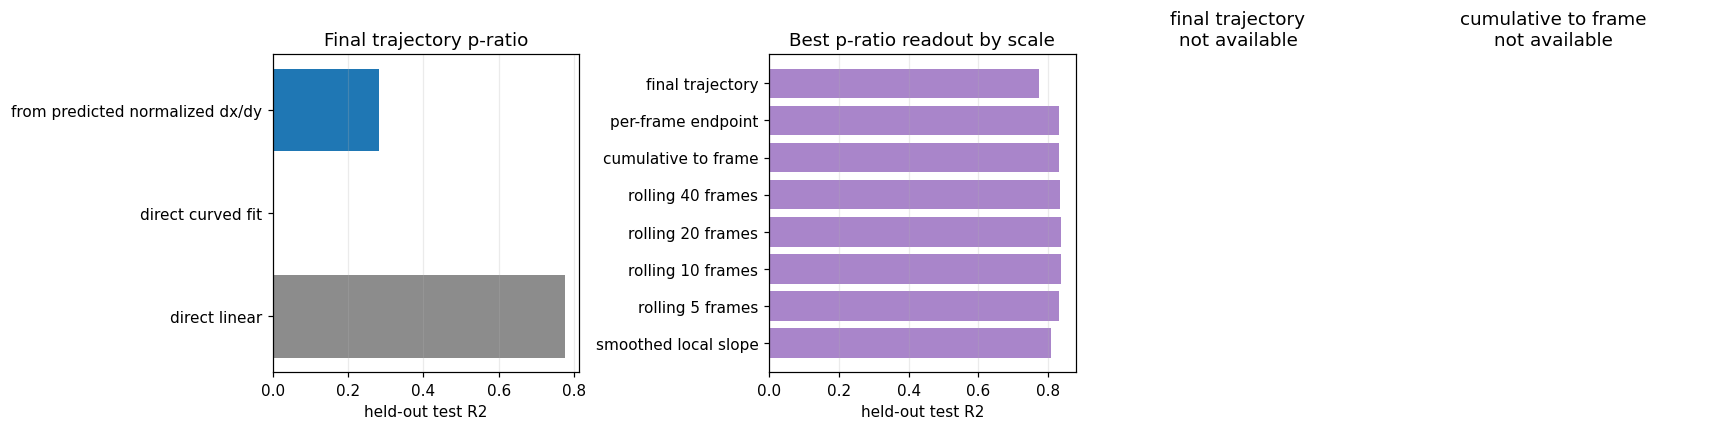

Best held-out p-ratio readouts
final trajectory: R2=0.774 using latent state
per-frame endpoint: R2=0.829 using latent state
cumulative to frame: R2=0.830 using latent state
rolling 40 frames: R2=0.833 using latent state
rolling 20 frames: R2=0.836 using latent state
rolling 10 frames: R2=0.836 using latent state
rolling 5 frames: R2=0.832 using latent state
smoothed local slope: R2=0.807 using latent state


In [8]:
p_ratio_labels = {
    'side_final_trajectory_p_ratio': 'final trajectory',
    'side_endpoint_p_ratio': 'per-frame endpoint',
    'side_cumulative_p_ratio': 'cumulative to frame',
    'side_rolling_40_p_ratio': 'rolling 40 frames',
    'side_rolling_20_p_ratio': 'rolling 20 frames',
    'side_rolling_10_p_ratio': 'rolling 10 frames',
    'side_rolling_5_p_ratio': 'rolling 5 frames',
    'side_local_p_ratio': 'smoothed local slope',
}
p_ratio_scores = descriptor_score_df[
    descriptor_score_df['target'].isin(p_ratio_labels)
].copy()
best_by_target = (
    p_ratio_scores.sort_values('test_r2', ascending=False)
    .drop_duplicates('target')
)

final_methods = [
    'latent state',
    'quadratic latent state',
    'latent state via side strains',
    'quadratic latent state via side strains',
]
final_comparison = p_ratio_scores[
    p_ratio_scores['target'].eq('side_final_trajectory_p_ratio')
    & p_ratio_scores['feature_set'].isin(final_methods)
].set_index('feature_set').reindex(final_methods).reset_index()

fig, axes = plt.subplots(1, 4, figsize=(15.5, 3.8), constrained_layout=True)
method_labels = [
    'direct linear', 'direct curved fit',
    'from predicted normalized dx/dy',
    'curved fit to normalized dx/dy',
]
axes[0].barh(method_labels, final_comparison['test_r2'], color=['0.55', '0.4', 'tab:blue', 'tab:green'])
axes[0].set(title='Final trajectory p-ratio', xlabel='held-out test R2')
axes[0].grid(axis='x', alpha=0.25)

timescale_order = [
    'side_local_p_ratio', 'side_rolling_5_p_ratio', 'side_rolling_10_p_ratio',
    'side_rolling_20_p_ratio', 'side_rolling_40_p_ratio',
    'side_cumulative_p_ratio', 'side_endpoint_p_ratio',
    'side_final_trajectory_p_ratio',
]
timescale_scores = best_by_target.set_index('target').reindex(timescale_order).dropna(subset=['test_r2'])
axes[1].barh(
    [p_ratio_labels[target] for target in timescale_scores.index],
    timescale_scores['test_r2'], color='tab:purple', alpha=0.8,
)
axes[1].set(title='Best p-ratio readout by scale', xlabel='held-out test R2')
axes[1].grid(axis='x', alpha=0.25)

scatter_specs = [
    ('side_final_trajectory_p_ratio', 'quadratic latent state via side strains'),
    ('side_cumulative_p_ratio', 'quadratic latent state via side strains'),
]
p_ratio_temperatures = descriptor_prediction_df['temperature'].to_numpy(float)
color_by_source = 'source' in descriptor_prediction_df and descriptor_prediction_df['source'].nunique(dropna=True) > 1
color_by_temperature = (not color_by_source) and np.isfinite(p_ratio_temperatures).any()
temperature_points = None
source_legend_ax = None
for ax, (target, feature_set) in zip(axes[2:], scatter_specs):
    sub = descriptor_prediction_df[
        descriptor_prediction_df['target'].eq(target)
        & descriptor_prediction_df['feature_set'].eq(feature_set)
    ].copy()
    if target == 'side_final_trajectory_p_ratio':
        sub = sub.drop_duplicates('sim_idx')
    score_rows = p_ratio_scores.loc[
        p_ratio_scores['target'].eq(target)
        & p_ratio_scores['feature_set'].eq(feature_set),
        'test_r2',
    ]
    if sub.empty or score_rows.empty:
        ax.set(title=f'{p_ratio_labels[target]}\nnot available')
        ax.axis('off')
        continue
    if color_by_source:
        for source, group in sub.groupby('source', sort=True):
            ax.scatter(
                group['observed'], group['predicted'], s=12, alpha=0.45,
                rasterized=True, color=source_palette.get(str(source)), label=str(source),
            )
        source_legend_ax = ax
    else:
        scatter_kwargs = {'c': sub['temperature'], 'cmap': 'viridis'} if color_by_temperature else {'color': 'tab:blue'}
        points = ax.scatter(
            sub['observed'], sub['predicted'], s=12, alpha=0.35,
            rasterized=True, **scatter_kwargs,
        )
        if color_by_temperature:
            temperature_points = points
    lo, hi = np.nanmin(np.r_[sub['observed'], sub['predicted']]), np.nanmax(np.r_[sub['observed'], sub['predicted']])
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
    score = score_rows.iloc[0]
    ax.set(
        title=f'{p_ratio_labels[target]}\nR2={score:.3f}',
        xlabel='observed p-ratio', ylabel='latent-derived p-ratio',
    )
    ax.grid(alpha=0.25)
if temperature_points is not None:
    fig.colorbar(temperature_points, ax=axes[2:], pad=0.01, label='temperature')
if source_legend_ax is not None:
    source_legend_ax.legend(frameon=False, fontsize=8, title='source')
plt.show()

print('Best held-out p-ratio readouts')
for target in timescale_order[::-1]:
    row = best_by_target[best_by_target['target'].eq(target)]
    if row.empty:
        continue
    row = row.iloc[0]
    method = row.feature_set.replace('side strains', 'predicted normalized dx/dy')
    method = method.replace('quadratic', 'curved')
    print(f'{p_ratio_labels[target]}: R2={row.test_r2:.3f} using {method}')


## DePablo Zero-Shot Check

This block audits the split and reports source-specific scores for the final-trajectory p-ratio readout. The readout above is fit on validation rows only; with the mixture config, dePablo is held out of train and validation and appears only in test.


In [9]:
def _sim_source_name(sim):
    if not sim:
        return 'unknown'
    return str(getattr(sim[0], 'source_name', result.get('source_name', result['label'])))


split_source_counts = pd.DataFrame(
    [
        {'split': split, 'source': _sim_source_name(sim)}
        for split in ('train', 'val', 'test')
        for sim in result[f'{split}_data']
    ]
).value_counts(['split', 'source']).rename('n_sims').reset_index()
split_source_counts.to_csv(run_dir / 'source_split_counts.csv', index=False)

source_split_table = (
    split_source_counts.pivot(index='source', columns='split', values='n_sims')
    .fillna(0)
    .astype(int)
    .reindex(columns=['train', 'val', 'test'], fill_value=0)
)
display(source_split_table)

ood_source = 'depablo' if 'depablo' in source_split_table.index else selected_dataset
fit_count = int(source_split_table.loc[ood_source, ['train', 'val']].sum()) if ood_source in source_split_table.index else 0
test_count = int(source_split_table.loc[ood_source, 'test']) if ood_source in source_split_table.index else 0
if fit_count:
    print(f'WARNING: {ood_source} appears in train/val ({fit_count} sims), so this is not a zero-shot dePablo check.')
else:
    print(f'Zero-shot split audit: {ood_source} has 0 train/val sims and {test_count} test sims.')

proof_target = 'side_final_trajectory_p_ratio'
proof_feature_set = 'quadratic latent state via side strains'
proof_df = descriptor_prediction_df[
    descriptor_prediction_df['target'].eq(proof_target)
    & descriptor_prediction_df['feature_set'].eq(proof_feature_set)
].copy()
proof_df = proof_df.sort_values('frame_idx').drop_duplicates(['source', 'sim_idx'], keep='last')

source_score_rows = []
for source, group in proof_df.groupby('source', sort=True):
    observed = group['observed'].to_numpy(float)
    predicted = group['predicted'].to_numpy(float)
    valid = np.isfinite(observed) & np.isfinite(predicted)
    if int(valid.sum()) < 3:
        continue
    source_score_rows.append(
        {
            'source': source,
            'target': proof_target,
            'feature_set': proof_feature_set,
            'n_test_sims': int(valid.sum()),
            'r2': r2_score(observed[valid], predicted[valid]),
            'pearson_r': pearson_r(observed[valid], predicted[valid]),
            'observed_mean': float(np.nanmean(observed[valid])),
            'predicted_mean': float(np.nanmean(predicted[valid])),
        }
    )
ood_p_ratio_source_scores_df = pd.DataFrame(source_score_rows)
ood_p_ratio_source_scores_df.to_csv(run_dir / 'depablo_zero_shot_final_p_ratio_scores.csv', index=False)
display(ood_p_ratio_source_scores_df.round(6))

if not proof_df.empty:
    fig, ax = plt.subplots(figsize=(4.8, 4.2), constrained_layout=True)
    scatter_by_source(ax, proof_df, 'observed', 'predicted', s=38, alpha=0.85)
    lo, hi = np.nanmin(proof_df[['observed', 'predicted']].to_numpy(float)), np.nanmax(proof_df[['observed', 'predicted']].to_numpy(float))
    pad = 0.05 * max(hi - lo, 1e-6)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], 'k--', lw=1)
    ax.set(
        xlim=(lo - pad, hi + pad),
        ylim=(lo - pad, hi + pad),
        title='Zero-shot final p-ratio readout',
        xlabel='observed final trajectory p-ratio',
        ylabel='latent-derived p-ratio',
    )
    ax.legend(frameon=False, fontsize=8, title='source')
    ax.grid(alpha=0.25)
    plt.show()


split,train,val,test
source,,,
depablo,10,10,180
reid,10,10,82


""


## Autoregressive Rollout


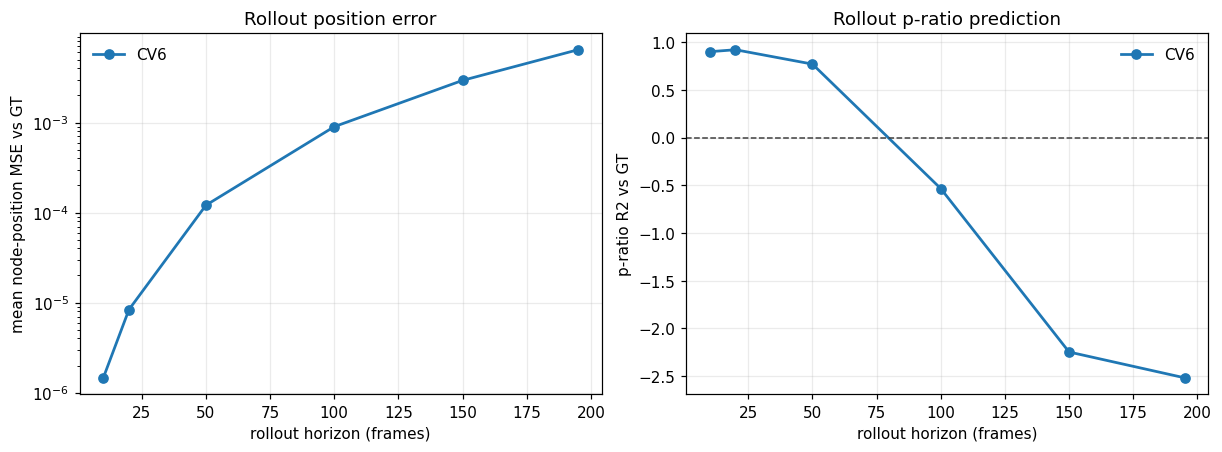

,latent_dim,split,rollout_steps,final_pos_mse,p_ratio_mse,used,p_ratio_r2,p_ratio_pearson
0,6,test,10,0.000001,0.005660,262,0.900968,0.952130
1,6,test,20,0.000008,0.005394,262,0.921317,0.960457
2,6,test,50,0.000121,0.017969,262,0.770550,0.944847
3,6,test,100,0.000899,0.129416,262,-0.534082,0.897410
4,6,test,150,0.002936,0.287503,262,-2.247267,0.843671
5,6,test,195,0.006433,0.323290,262,-2.517663,0.692900


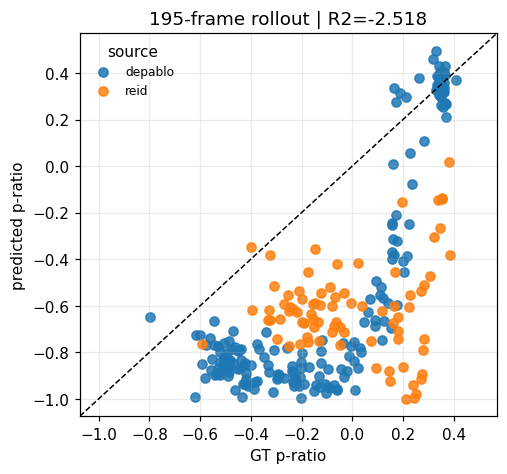

In [10]:
rollout_by_repeat_df, rollout_curve_df = rollout_curve_summary(rollout_rows_df)
rollout_by_repeat_df.to_csv(run_dir / 'rollout_error_vs_steps_by_repeat.csv', index=False)
rollout_curve_df.to_csv(run_dir / 'rollout_error_vs_steps.csv', index=False)

test_curve = rollout_curve_df[rollout_curve_df['split'].eq('test')].sort_values('rollout_steps')
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for latent_dim, group in test_curve.groupby('latent_dim'):
    label = f'CV{int(latent_dim)}'
    axes[0].plot(group['rollout_steps'], group['final_pos_mse'], marker='o', lw=1.8, label=label)
    axes[1].plot(group['rollout_steps'], group['p_ratio_r2'], marker='o', lw=1.8, label=label)
axes[0].set(
    title='Rollout position error',
    xlabel='rollout horizon (frames)',
    ylabel='mean node-position MSE vs GT',
    yscale='log',
)
axes[1].set(
    title='Rollout p-ratio prediction',
    xlabel='rollout horizon (frames)',
    ylabel='p-ratio R2 vs GT',
)
axes[1].axhline(0, color='0.25', lw=1, ls='--')
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
plt.show()

display(test_curve.round(6))

if not rollout_rows_df.empty:
    chosen_step = int(rollout_rows_df.loc[rollout_rows_df['split'].eq('test'), 'rollout_steps'].max())
    scatter_df = rollout_rows_df[
        rollout_rows_df['split'].eq('test')
        & rollout_rows_df['rollout_steps'].eq(chosen_step)
    ]
    x = scatter_df['true_p_ratio'].to_numpy(float)
    y = scatter_df['pred_p_ratio'].to_numpy(float)
    lo, hi = np.nanmin(np.r_[x, y]), np.nanmax(np.r_[x, y])
    pad = 0.05 * max(hi - lo, 1e-6)

    fig, ax = plt.subplots(figsize=(4.5, 4.2), constrained_layout=True)
    temperatures = scatter_df['temperature'].to_numpy(float)
    if 'source' in scatter_df and scatter_df['source'].nunique(dropna=True) > 1:
        scatter_by_source(ax, scatter_df, 'true_p_ratio', 'pred_p_ratio', s=36, alpha=0.85)
        ax.legend(frameon=False, fontsize=8, title='source')
    elif np.isfinite(temperatures).sum() and len(np.unique(temperatures[np.isfinite(temperatures)])) > 1:
        points = ax.scatter(x, y, c=temperatures, cmap='viridis', s=36, alpha=0.85)
        fig.colorbar(points, ax=ax, pad=0.02, label='temperature')
    else:
        ax.scatter(x, y, s=36, alpha=0.85)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], 'k--', lw=1)
    ax.set(
        xlim=(lo - pad, hi + pad), ylim=(lo - pad, hi + pad),
        title=f'{chosen_step}-frame rollout | R2={r2_score(x, y):.3f}',
        xlabel='GT p-ratio', ylabel='predicted p-ratio',
    )
    ax.grid(alpha=0.25)
    plt.show()
